In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

In [3]:
from Compression.Benchmarks.MOPED import moped
from Compression.compressors import IBCompressor
from Compression.conditional_prob_models import ConditionalKDE, ConditionalNormalizingFlow
from Compression.ib import IB, Bounds
from Compression.mine import Mine
from Compression.tuba import TUBA, DV_with_Jensen

from ModelEvaluation.posterior_comparison import evaluate_posterior_covariance

from SupernovaDataset.config import DATAPOINT_SIZE, DATA_VARIANCE_SCALE, LOAD_DATASET
from SupernovaDataset.config import NUM_TRAIN, NUM_TEST, LATENT_SIZE
from SupernovaDataset.dataset_creation import create_torch_supernovae_dataset, create_synthetic_supernovae_dataset


In [4]:
bounds = [
    # Bounds(name="BA_KDE", cond_prob_model_class=ConditionalKDE, **{"init_std": 1, "num_kde_points": 10}),
    # Bounds(name="BA_NF", cond_prob_model_class=ConditionalNormalizingFlow, **{"num_flows": 8}),
    # Bounds(name="DV", cond_prob_model_class=Mine, **{"y_dim": 1, "z_dim": LATENT_SIZE, "alpha": 0e0}),
    # Bounds(name="DV_with_Jensen", cond_prob_model_class=DV_with_Jensen, **{"y_dim": 1, "z_dim": LATENT_SIZE}),
    Bounds(name="MINE", cond_prob_model_class=Mine, **{"y_dim": 1, "z_dim": LATENT_SIZE, "alpha": 1e-2}),
    # Bounds(name="TUBA", cond_prob_model_class=TUBA, **{"y_dim": 1, "z_dim": LATENT_SIZE, "hidden_dim": 400}),
    # Bounds(name="NWJ", cond_prob_model_class=TUBA, **{"y_dim": 1, "z_dim": LATENT_SIZE, "hidden_dim": 400, "a": lambda z: torch.tensor(np.exp(1.0), device=device)})
]

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Running on device:", device)

Running on device: cuda


## Train MOPED

In [6]:
cov = np.eye(DATAPOINT_SIZE) * DATA_VARIANCE_SCALE**2

def estimator_given_theta(theta):
    _, data, _, _ = create_synthetic_supernovae_dataset(1, theta, data_var=0.)
    # print(data.shape)
    # return 10**(-0.4*data[0, :])
    return data[0, :]
moped_fid_val = np.array([70.0**2])

b, F, d = moped(moped_fid_val, cov, estimator_given_theta)
def moped_model(data):
    if (type(data) != np.ndarray):
        data = data# .detach().cpu().numpy()
    return data[:, :DATAPOINT_SIZE] @ b.T

Creating sample: 1 of 1
Creating sample: 1 of 1
Creating sample: 1 of 1
(1, 100)


## Train IBs

### Training data

In [7]:
train_sims_data, test_sims_data, _ = create_torch_supernovae_dataset(NUM_TRAIN, NUM_TEST, epsilon=0.)

train_sims_data = train_sims_data.to(device)
test_sims_data = test_sims_data.to(device)

Creating sample: 10000 of 10000
Creating sample: 50000 of 50000


In [8]:
class Compressor(nn.Module):
    def __init__(self, input_size=DATAPOINT_SIZE, latent_size=LATENT_SIZE):
        super(Compressor, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_size, 1024),
            nn.LeakyReLU(0.2),

            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 64),
            nn.LeakyReLU(0.2),

            nn.Linear(64, 32),
            nn.LeakyReLU(0.2),
            
            nn.Linear(32, 2*latent_size)
        )

    def forward(self, x):
        return self.encoder(x)

In [22]:
betas = np.linspace(0.0, .3, 7)
compressors = [Compressor() for _ in betas]
ib_models = [
    IB(
        encoder=IBCompressor(encoder=compressor, x_dim=DATAPOINT_SIZE, z_dim=LATENT_SIZE),
        cond_prob_model=bounds[0].cond_prob_model(**bounds[0].cond_prob_model_kwargs),
        beta=beta,
        reg_weight=4e-2,
        reg_type=0,
        optim_func=torch.optim.Adam,
        lr=1e-4
        ).to(device)
    for compressor, beta in zip(compressors, betas)
]

h02s = train_sims_data[:, -1:]
h02_norm = (h02s - h02s.mean()) / h02s.std()

Training with beta: 0.0
Epoch 1: Loss=2.9946, log_q=-2.9610,, reg. loss=0.0336, beta * KL=0.5141
Epoch 10: Loss=0.7613, log_q=-0.7612,, reg. loss=0.0001, beta * KL=36.9857
Epoch 20: Loss=-0.3462, log_q=0.3463,, reg. loss=0.0001, beta * KL=36.9117
Epoch 30: Loss=-0.5433, log_q=0.5433,, reg. loss=0.0001, beta * KL=36.1347
Epoch 40: Loss=-0.6844, log_q=0.6844,, reg. loss=0.0001, beta * KL=36.7562
Epoch 50: Loss=-0.7841, log_q=0.7841,, reg. loss=0.0001, beta * KL=36.2128


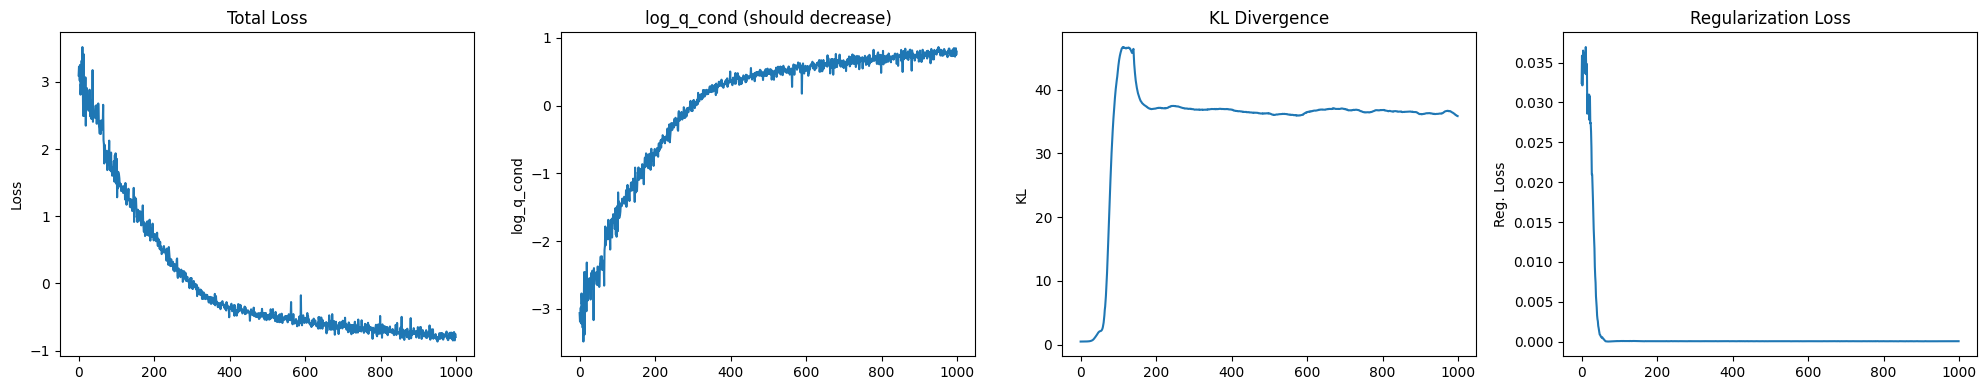

Training with beta: 0.049999999999999996
Epoch 1: Loss=0.4764, log_q=-0.4159,, reg. loss=0.0343, beta * KL=0.5265
Epoch 10: Loss=0.0926, log_q=-0.0442,, reg. loss=0.0153, beta * KL=0.6620
Epoch 20: Loss=0.0793, log_q=-0.0305,, reg. loss=0.0155, beta * KL=0.6660
Epoch 30: Loss=0.0717, log_q=-0.0226,, reg. loss=0.0155, beta * KL=0.6730
Epoch 40: Loss=0.0720, log_q=-0.0233,, reg. loss=0.0154, beta * KL=0.6664
Epoch 50: Loss=0.0643, log_q=-0.0152,, reg. loss=0.0155, beta * KL=0.6710


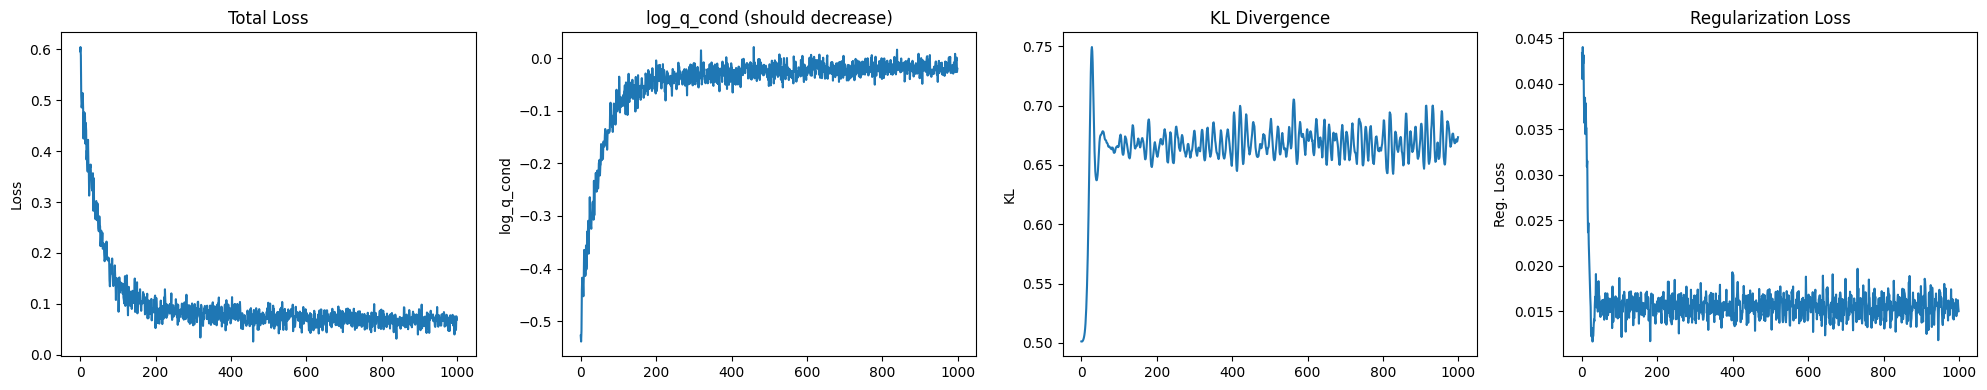

Training with beta: 0.09999999999999999
Epoch 1: Loss=1.5395, log_q=-1.4542,, reg. loss=0.0336, beta * KL=0.5170
Epoch 10: Loss=0.3576, log_q=-0.2782,, reg. loss=0.0224, beta * KL=0.5700
Epoch 20: Loss=0.1395, log_q=-0.0600,, reg. loss=0.0224, beta * KL=0.5711
Epoch 30: Loss=0.1267, log_q=-0.0473,, reg. loss=0.0223, beta * KL=0.5709
Epoch 40: Loss=0.1145, log_q=-0.0349,, reg. loss=0.0224, beta * KL=0.5710
Epoch 50: Loss=0.1023, log_q=-0.0228,, reg. loss=0.0223, beta * KL=0.5728


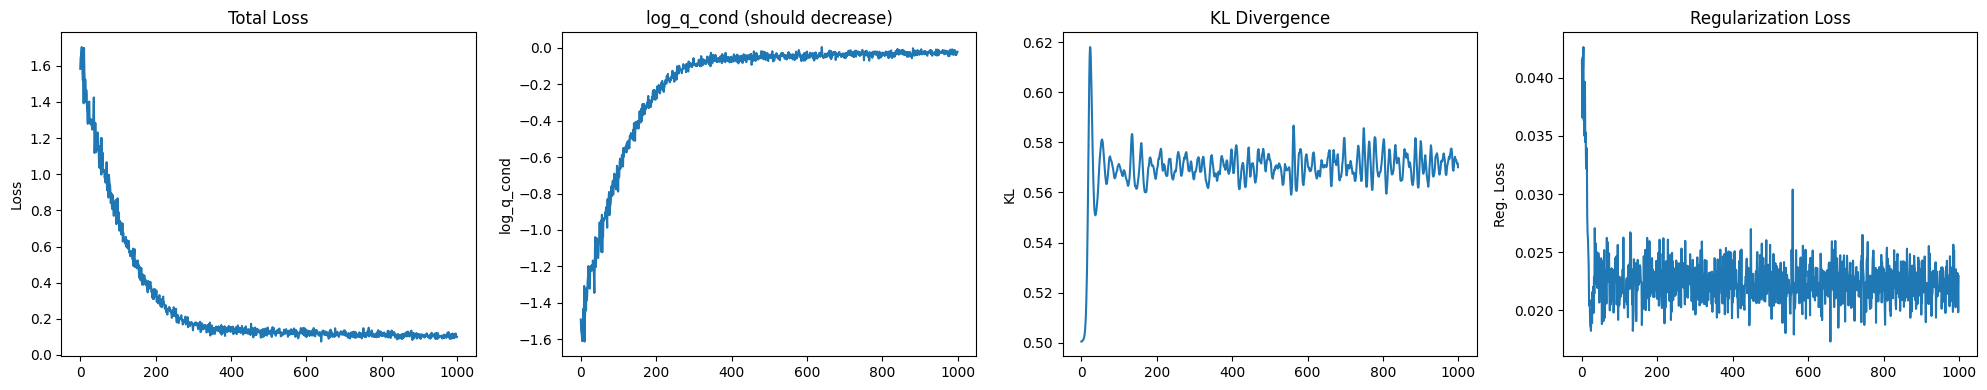

Training with beta: 0.15
Epoch 1: Loss=3.1036, log_q=-2.9893,, reg. loss=0.0389, beta * KL=0.5028
Epoch 10: Loss=0.7973, log_q=-0.6908,, reg. loss=0.0257, beta * KL=0.5388
Epoch 20: Loss=0.1732, log_q=-0.0663,, reg. loss=0.0259, beta * KL=0.5400
Epoch 30: Loss=0.1586, log_q=-0.0512,, reg. loss=0.0263, beta * KL=0.5405
Epoch 40: Loss=0.1546, log_q=-0.0476,, reg. loss=0.0259, beta * KL=0.5406
Epoch 50: Loss=0.1380, log_q=-0.0317,, reg. loss=0.0255, beta * KL=0.5391


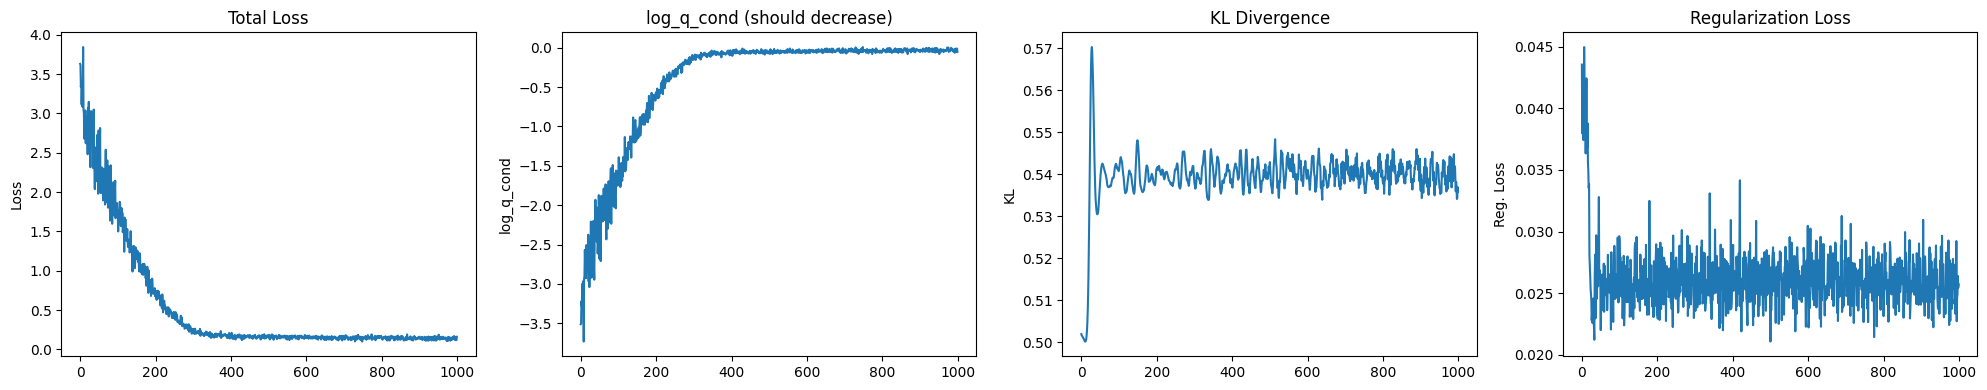

Training with beta: 0.19999999999999998
Epoch 1: Loss=0.9333, log_q=-0.7989,, reg. loss=0.0310, beta * KL=0.5171
Epoch 10: Loss=0.3021, log_q=-0.1677,, reg. loss=0.0278, beta * KL=0.5329
Epoch 20: Loss=0.1805, log_q=-0.0462,, reg. loss=0.0290, beta * KL=0.5265
Epoch 30: Loss=0.1443, log_q=-0.0065,, reg. loss=0.0271, beta * KL=0.5534
Epoch 40: Loss=0.1438, log_q=-0.0046,, reg. loss=0.0282, beta * KL=0.5552


KeyboardInterrupt: 

In [23]:
for i, beta in enumerate(betas):
    print(f"Training with beta: {beta}")
    ib_model = ib_models[i]
    ib_model.train(
        x_train=train_sims_data[:, :DATAPOINT_SIZE],
        y_train=h02_norm,
        nepochs=50,
        batch_size=512,
        print_losses=True
    )
    assert not np.isnan(ib_model.full_losses[-1]), "Total loss is NaN. Check the model and training process."

## Sweeping over Betas

In [24]:
epsilons = np.linspace(0.0, 1.0, 7)

In [25]:
moped_scores = []
moped_score_errors = []
mi_bound_scores = [[] for _ in betas]
mi_bound_score_errors = [[] for _ in betas]
for eps in epsilons:
    # Generate dataset with current epsilon
    test_sims_data, _, _ = create_torch_supernovae_dataset(NUM_TRAIN*10, 1, epsilon=eps, print_status=False)
    # Evaluate MOPED compression/reconstruction score


    moped_sigma, _, _, moped_std_error = evaluate_posterior_covariance(
        moped_model,
        test_sims_data[:, :DATAPOINT_SIZE],
        test_sims_data[:, -1:],
        plot_results=False,
        print_results=False
    )

    moped_sigma += 1e-6  # Avoid division by zero

    moped_scores.append(1.0 / (moped_sigma**2))
    moped_score_errors.append(2.0 * moped_std_error.mean() / (moped_sigma ** 3))

    for i, beta in enumerate(betas):
        ib_model = ib_models[i]
        # Evaluate Neural MI Bound compression score
        mi_bound_sigma, _, _, mi_bound_std_error = evaluate_posterior_covariance(
            ib_model,
            test_sims_data[:, :DATAPOINT_SIZE].to(device),
            test_sims_data[:, -1:].to(device),
            plot_results=False,
            print_results=False
        )
        mi_bound_scores[i].append(1.0 / (mi_bound_sigma**2))
        mi_bound_score_errors[i].append(2.0 * mi_bound_std_error.mean() / (mi_bound_sigma ** 3))
        print(f"Epsilon {eps:<10.3f} Evaluated beta = {beta:.3f}: score={mi_bound_scores[i][-1]:.3f}+/-{mi_bound_score_errors[i][-1]:.3f}")

    print(f"Epsilon {eps:<10.3f}: MOPED score = {moped_scores[-1]:.3f}+/-{moped_score_errors[-1]:.3f}")

C:\Users\srish\AppData\Local\Temp\ipykernel_24340\3665724087.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return data[:, :DATAPOINT_SIZE] @ b.T


Epsilon 0.000      Evaluated beta = 0.000: score=0.017+/-0.003
Epsilon 0.000      Evaluated beta = 0.050: score=0.005+/-0.001
Epsilon 0.000      Evaluated beta = 0.100: score=0.006+/-0.001
Epsilon 0.000      Evaluated beta = 0.150: score=0.002+/-0.000
Epsilon 0.000      Evaluated beta = 0.200: score=0.002+/-0.000
Epsilon 0.000      Evaluated beta = 0.250: score=0.002+/-0.000
Epsilon 0.000      Evaluated beta = 0.300: score=0.002+/-0.000
Epsilon 0.000     : MOPED score = 0.018+/-0.003
Epsilon 0.167      Evaluated beta = 0.000: score=0.005+/-0.002
Epsilon 0.167      Evaluated beta = 0.050: score=0.002+/-0.001
Epsilon 0.167      Evaluated beta = 0.100: score=0.003+/-0.000
Epsilon 0.167      Evaluated beta = 0.150: score=0.002+/-0.000
Epsilon 0.167      Evaluated beta = 0.200: score=0.002+/-0.000
Epsilon 0.167      Evaluated beta = 0.250: score=0.002+/-0.001
Epsilon 0.167      Evaluated beta = 0.300: score=0.002+/-0.000
Epsilon 0.167     : MOPED score = 0.005+/-0.001
Epsilon 0.333      Eva

C:\Users\srish\AppData\Local\Temp\ipykernel_24340\568187006.py:33: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim([0, 3e-2])


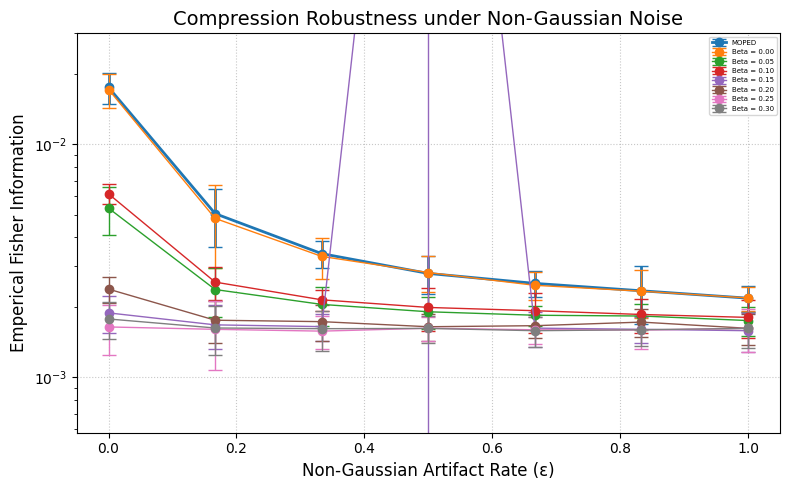

In [29]:
plt.figure(figsize=(8, 5))

# Use fmt='-o' to draw a solid line (-) with circle markers (o)
# Matplotlib will automatically use the same color for the line, marker, and error bars
plt.errorbar(
    epsilons, 
    moped_scores, 
    yerr=moped_score_errors, 
    fmt='-o', 
    capsize=5, 
    label="MOPED", 
    linewidth=2
)

for i, beta in enumerate(betas):
    plt.errorbar(
        epsilons, 
        mi_bound_scores[i], 
        yerr=mi_bound_score_errors[i], 
        fmt='-o', 
        capsize=5, 
        label=f"Beta = {beta:.2f}",
        linewidth=1
    )
    # if i == 3:
    #     break

# Updated the labels to match the metrics we discussed!
plt.xlabel("Non-Gaussian Artifact Rate (\u03B5)", fontsize=12)
plt.ylabel("Emperical Fisher Information", fontsize=12)

plt.yscale('log')
plt.ylim([0, 3e-2])

plt.title("Compression Robustness under Non-Gaussian Noise", fontsize=14)
plt.legend(fontsize=5)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

C:\Users\srish\AppData\Local\Temp\ipykernel_12788\2651099955.py:15: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim([0, 3e-2])


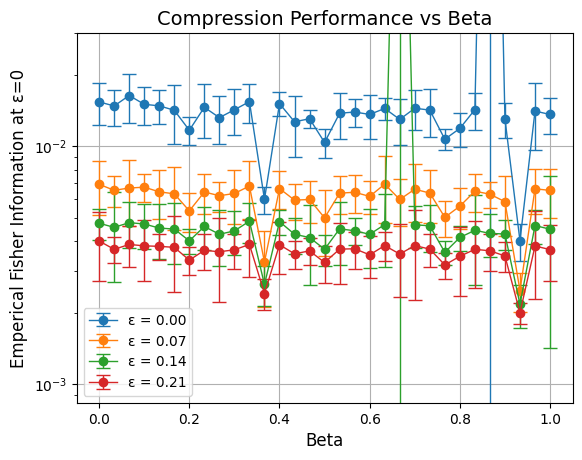

In [ ]:
FI_at_eps = [[mi_bound_scores[i][j] for i in range(len(betas))] for j in range(len(epsilons))]
FI_at_eps_errors = [[mi_bound_score_errors[i][j] for i in range(len(betas))] for j in range(len(epsilons))]
for j in range(len(epsilons)):
    plt.errorbar(betas,
            FI_at_eps[j], 
            yerr=FI_at_eps_errors[j],
            fmt='-o', 
            capsize=5,
            label=f"\u03B5 = {epsilons[j]:.2f}",
            linewidth=1
        )
    if j == 3:
        break
plt.yscale('log')
plt.ylim([0, 3e-2])
plt.xlabel("Beta", fontsize=12)
plt.ylabel("Emperical Fisher Information at \u03B5=0", fontsize=12)
plt.title("Compression Performance vs Beta", fontsize=14)
plt.legend()
plt.grid()
plt.show()